    Bernacchia Alessia, Pioda Tommaso, Villani Giacomo
    Data Project and Hackaton 3
    _Sandra Mitròvich_

In [1]:
from utils.data import *

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import os
import pyarrow.parquet as pq
from tqdm.auto import tqdm
tqdm.pandas()

os.makedirs("data", exist_ok=True)

RANDOM_SEED = 21
# 35

from utils.splitting import *

# path to the Parquet files folder
CLEANED_DATA_PATH = "data/cleaned_parquet"
SPLIT_DATA_PATH = "data/split"

# utils paths
ID_REGISTRY_PATH = "data/ids_registry.parquet"

# splitting parameters
RANGE_YEARS_FOR_SPLITTING = range(1971, 2025) 
N_TRAIN_PAPERS = 500_000
N_VALIDATION_PAPERS = 150_000  
N_TEST_PAPERS = 150_000


densitz of the graph, how connected the graph is

# B - Split datataset

We consider only papers published between 1971 and 2024 (included). Before 1971 the number of publications per year is very low, while after 2024 not enough papers are available.

The dataset is split into train, validation and test sets using a year‑weighted strategy. The number of papers selected per year is proportional to the actual publication papers of that year.

This approach preserves the real temporal distribution of scientific research and avoids bias. Earlier years are not over‑represented, and more recent years are not under‑sampled, ensuring a more realistic and representative training dataset.

Key features of this implementation:
Shared Logic: The get_year_color function is defined internally to ensure consistent coloring between the weight bar and the paper subplots.

sharex=True: In the 'papers' subplot mode, all three plots share the same X-axis. This makes it visually obvious that the data is partitioned: the Blue bars stop where the Yellow bars begin, and so on.

Automatic Alignment: For the subplots, the code iterates through the entire RANGE_YEARS_FOR_SPLITTING. This ensures that even if a set (like 'Test') only has data for 2020-2024, the plot doesn't "stretch" those bars; it places them correctly at the end of the timeline.

Flexibility: Calling the function without arguments will generate both views, which is useful for a final inspection of your data splitting strategy.

## 1. Downsample from Cleaned Data
- rescale the dataset in a given year range on which focus the study
- balance maintaining the year distribution
- avoid overlapping years between sets
- avoid less than 3 years in a single set to be meaningfull and representative

### 1.1 Identify Years Range
- import the ids_registry to count the publication per year
- define weights to downsample a balanced dataset

In [3]:
try:
    print(f'Read and import file IDs raw data from: {ID_REGISTRY_PATH}')
    ids_registry = pd.read_parquet(ID_REGISTRY_PATH)
    print(f"Found {len(ids_registry)} unique IDs.")
except Exception as e:
    print(f"Error reading the file: {e}")

Read and import file IDs raw data from: data/ids_registry.parquet
Found 6729828 unique IDs.


In [4]:
# years publication 
year_counts = ids_registry['year'].value_counts().sort_index()
# filter for interested years
year_counts = year_counts.loc[year_counts.index.isin(RANGE_YEARS_FOR_SPLITTING)]
# total number of papers available in the interested years
total_available_papers = year_counts.sum()
# weights based on distr of papers per year,
# select more papers from the years with more publications and less from the years with less publications
year_weights = year_counts / total_available_papers

# target total papers
N_TOT = N_TRAIN_PAPERS + N_VALIDATION_PAPERS + N_TEST_PAPERS

### 1.2 Assign Years to Sets in a Chronological Order
- each set assigned to a set of years, at least 3 years to be representative

In [5]:
# cumulative sum to find where the thresholds fall
cumulative_weights = year_weights.cumsum()

# target percentages
train_pct = N_TRAIN_PAPERS / N_TOT
val_pct = N_VALIDATION_PAPERS / N_TOT

# find split years
train_end_year = cumulative_weights[cumulative_weights <= train_pct].index[-1]
val_end_year = cumulative_weights[cumulative_weights <= (train_pct + val_pct)].index[-1]

# define ranges
train_years = [y for y in RANGE_YEARS_FOR_SPLITTING if y <= train_end_year]
val_years = [y for y in RANGE_YEARS_FOR_SPLITTING if train_end_year < y <= val_end_year]
test_years = [y for y in RANGE_YEARS_FOR_SPLITTING if y > val_end_year]
# sanity check that we have at least N years in each set, otherwise we need to adjust the logic
min_years = 10

if not (check_N_years(test_years, "Test", min_years) and check_N_years(val_years, "Validation", min_years) and check_N_years(train_years, "Training", min_years)):
    # Fallback logic: Select last 3 for Test, previous 3 for Val, rest for Train
    all_years = sorted(list(RANGE_YEARS_FOR_SPLITTING))
    test_years = all_years[-min_years:]
    val_years = all_years[-(2 * min_years):-min_years]
    train_years = all_years[:- (2 * min_years)]
    print(f"Manual override: Train({min(train_years)}-{max(train_years)}), Val({min(val_years)}-{max(val_years)}), Test({min(test_years)}-{max(test_years)})")

Manual override: Train(1971-2004), Val(2005-2014), Test(2015-2024)


### 1.3 Assign papers per year
- assign how many papers to take from each year
- splitting avoiding data leakage, then they wouldn't be in the same time range

In [6]:
n_tr_per_year = get_papers_per_year(N_TRAIN_PAPERS, train_years, year_weights)
n_val_per_year = get_papers_per_year(N_VALIDATION_PAPERS, val_years, year_weights)
n_test_per_year = get_papers_per_year(N_TEST_PAPERS, test_years, year_weights)


print(f"Train Years(num of papers {n_tr_per_year.sum()}): {min(train_years)} - {max(train_years)}")
print(f"Val Years(num of papers {n_val_per_year.sum()}): {min(val_years)} - {max(val_years)}")
print(f"Test Years(num of papers {n_test_per_year.sum()}): {min(test_years)} - {max(test_years)}")

Train Years(num of papers 500000): 1971 - 2004
Val Years(num of papers 150000): 2005 - 2014
Test Years(num of papers 150000): 2015 - 2024


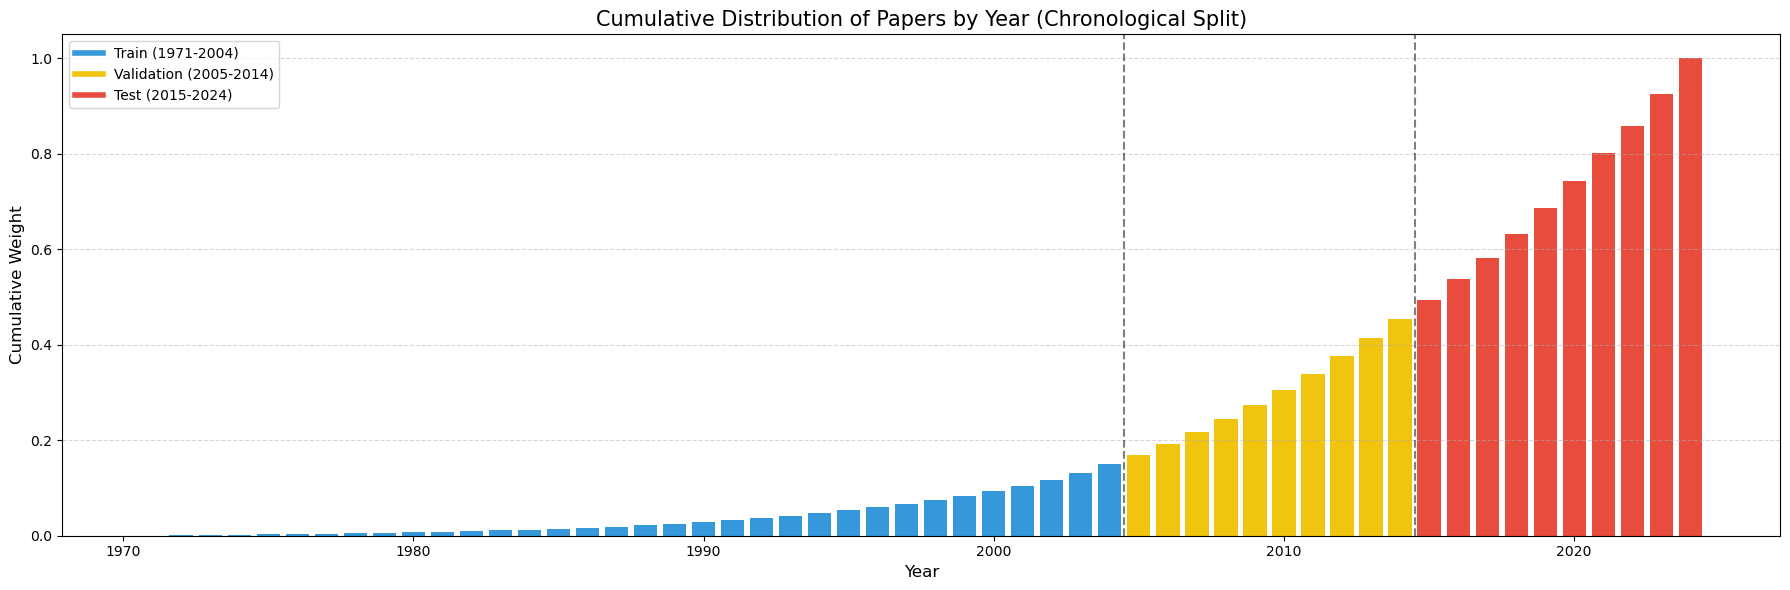

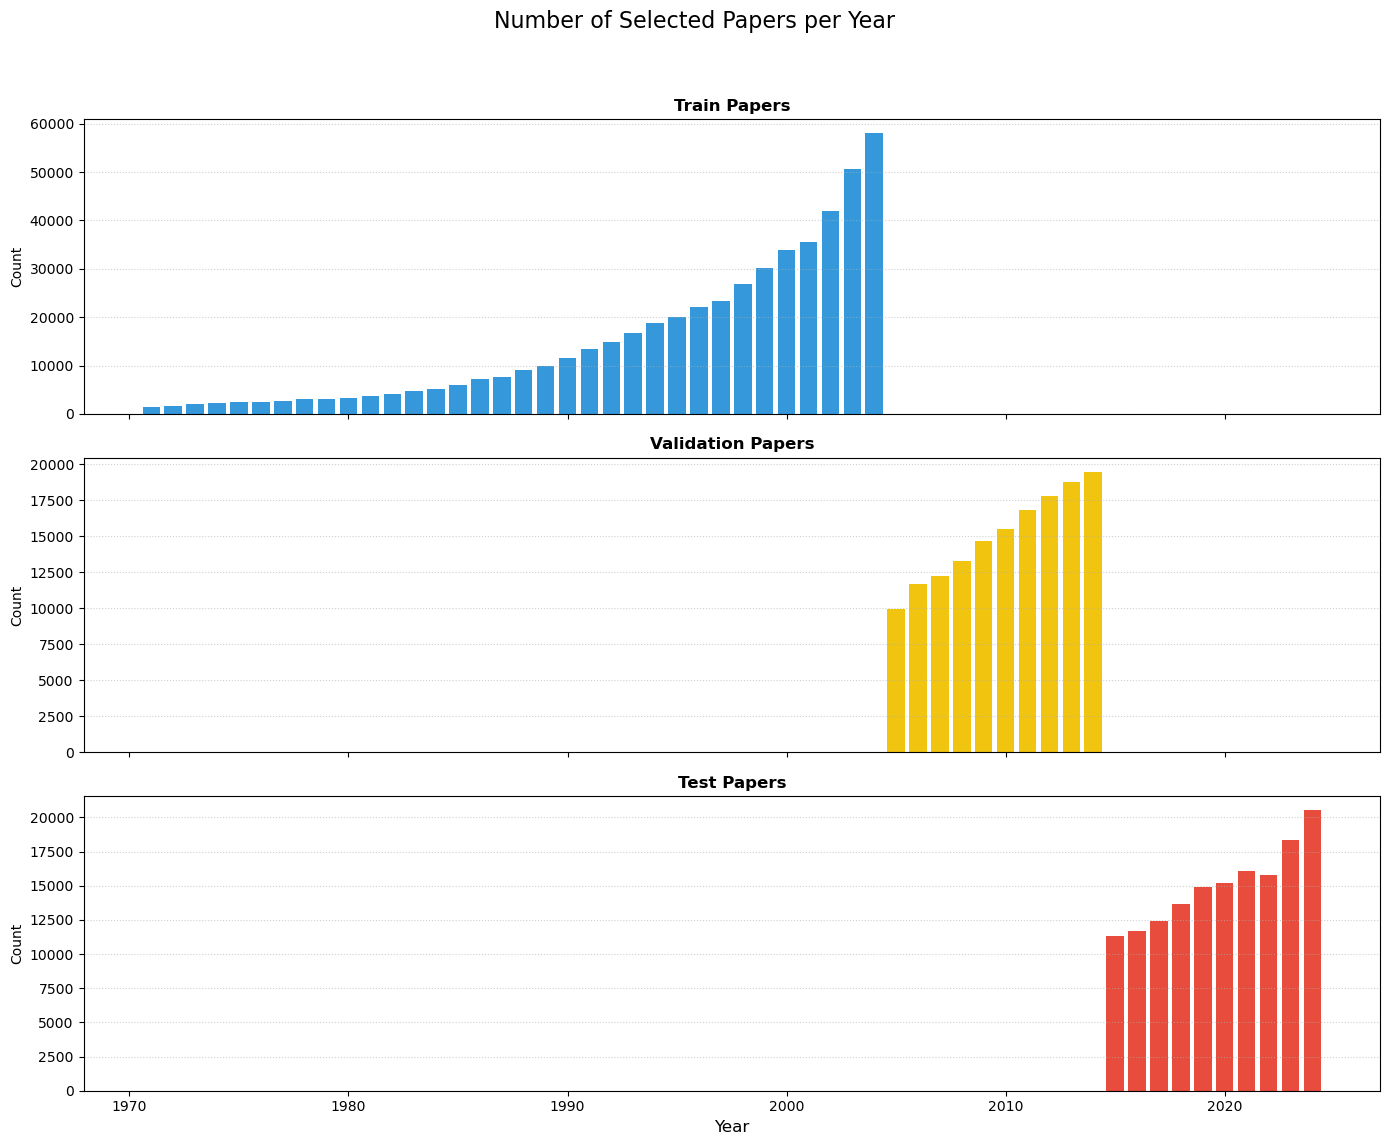

In [7]:
plot_split_distribution(cumulative_weights, (train_years, val_years, test_years), (n_tr_per_year, n_val_per_year, n_test_per_year), range_years=RANGE_YEARS_FOR_SPLITTING,mode=None)

## 2. Split dataset
- divide in train, validation and test set

In [8]:
train_list, val_list, test_list = [], [], []

for y in tqdm(train_years, desc="Sampling Train"):
    train_list.append(sample_from_year(y, n_tr_per_year[y], cleaned_data_path=CLEANED_DATA_PATH, random_state=RANDOM_SEED))

for y in tqdm(val_years, desc="Sampling Validation"):
    val_list.append(sample_from_year(y, n_val_per_year[y], cleaned_data_path=CLEANED_DATA_PATH, random_state=RANDOM_SEED))

for y in tqdm(test_years, desc="Sampling Test"):
    test_list.append(sample_from_year(y, n_test_per_year[y], cleaned_data_path=CLEANED_DATA_PATH, random_state=RANDOM_SEED))

# final concatenation
train_chunk = pd.concat(train_list, ignore_index=True)
val_chunk = pd.concat(val_list, ignore_index=True)
test_chunk = pd.concat(test_list, ignore_index=True)

# final global shuffle to mix the years within each set
train_chunk = train_chunk.sample(frac=1).reset_index(drop=True)
val_chunk = val_chunk.sample(frac=1).reset_index(drop=True)
test_chunk = test_chunk.sample(frac=1).reset_index(drop=True)

Sampling Train:   0%|          | 0/34 [00:00<?, ?it/s]

Sampling Validation:   0%|          | 0/10 [00:00<?, ?it/s]

Sampling Test:   0%|          | 0/10 [00:00<?, ?it/s]

In [9]:
print(f"Final Train set: {len(train_chunk)} papers")
display(train_chunk.head(3))

print(f"Final Validation set: {len(val_chunk)} papers")
display(val_chunk.head(3)) 

print(f"Final Test set: {len(test_chunk)} papers")
display(test_chunk.head(3))

Final Train set: 500000 papers


,id,title,lang,doc_type,venue,doi,abstract,year,n_citation,references,keywords,url,authors
0,53e9af53b7602d9703992aff,A Novel Common-Mode Noise Cancellation Techniq...,en,journal,IEEE Transactions on Instrumentation and Measu...,10.1109/tim.2003.816850,xDSL modems operate in frequency bands which c...,2003.0,36.0,[5390b63320f70186a0f18043],"[DSL, comnion-mode noise canceller, RFI]",[https://www.semanticscholar.org/paper/2903ce9...,"[{'id': '53f439efdabfaec22baa19b7', 'name': 'T..."
1,5390b61e20f70186a0f13de0,Network Operations-a Major Opportunity in Evol...,en,journal,IEEE Communications Magazine,10.1109/mcom.1986.1092938,NaN,1986.0,3.0,[],"[First Page, digital network, network operatio...",[https://www.semanticscholar.org/paper/fe83b10...,"[{'id': '53f447b7dabfaeb22f4c526b', 'name': 'J..."
2,53e9b3c7b7602d9703eb2ecb,Korean Compound Noun Decomposition Using Sylla...,en,conference,Conference on Intelligent Text Processing and ...,10.1007/978-3-540-24630-5_18,The compound nouns are freely composed in Kore...,2004.0,10.0,"[53e99a8cb7602d97023045d2, 53e9a789b7602d97030...",[Syntax-based Translation Models],[https://doi.org/10.1007/978-3-540-24630-5_18],"[{'id': '53f44d0bdabfaee43ec982b2', 'name': 'S..."


Final Validation set: 150000 papers


,id,title,lang,doc_type,venue,doi,abstract,year,n_citation,references,keywords,url,authors
0,53e99c4bb7602d97024fb72d,Partial Transmission High-Speed Continuous Tra...,en,conference,"Boston, MA",10.1109/bibe.2007.4375698,As a technique for compensating for tumor moti...,2007.0,10.0,"[5390962020f70186a0df49e2, 53e9b9c7b7602d97045...","[dynamic planning, tumor tracking, adaptive ra...","[https://doi.org/10.1109/BIBE.2007.4375698, h...","[{'id': '562f1f5045cedb339953df89', 'name': 'T..."
1,53e9a3c7b7602d9702cd6102,Universality of Coproducts in Categories of La...,en,journal,Applied Categorical Structures,10.1007/s10485-006-9019-6,"Categories of lax (T, V)-algebras are shown to...",2006.0,14.0,"[619b650f1c45e57ce9a0f5da, 5390881220f70186a0d...",None,[https://www.semanticscholar.org/paper/ff8fb78...,"[{'id': '53f45318dabfaee2a1d67480', 'name': 'M..."
2,5550439945ce0a409eb4858a,Delay Characterization and Performance Evaluat...,en,journal,FUTURE GENERATION COMPUTER SYSTEMS-THE INTERNA...,10.1016/j.future.2014.02.011,Provisioning of quality of service (QoS) is th...,2014.0,18.0,"[539099a220f70186a0e16f2d, 649fe8e2d68f896efa2...","[QoS wireless sensor networks, Random deployme...",None,"[{'id': '66828bb67ab40b3b688a96b0', 'name': 'U..."


Final Test set: 150000 papers


,id,title,lang,doc_type,venue,doi,abstract,year,n_citation,references,keywords,url,authors
0,63a413f690e50fcafd6d1e3e,Latent Planning Via Expansive Tree Search.,en,conference,NEURIPS 2022,NaN,Planning enables autonomous agents to solve co...,2022.0,13.0,"[5cda947be1cd8ecf46bb4910, 5f857f1391e011ff328...",None,[http://papers.nips.cc/paper_files/paper/2022/...,"[{'id': '63ab9cb7cb0eafdb3179c265', 'name': 'R..."
1,58d83014d649053542fe1c46,Utilising the Cross Industry Standard Process ...,en,conference,International Conference on Data Mining and Bi...,10.1007/978-3-319-40973-3_5,This paper investigates the application of Dat...,2016.0,6.0,"[53e99c4bb7602d97024fa1ca, 5550446145ce0a409eb...","[Measurement and Verification, Data mining, En...",[https://api.crossref.org/works/10.1007/978-3-...,"[{'id': '62e499a8d9f204418d6c1c2d', 'name': 'C..."
2,58d82fd2d649053542fd7e42,Informing the Development of an Internet-based...,en,journal,International Journal of Medical Informatics,10.1016/j.ijmedinf.2016.10.005,Background: Self-management can optimize healt...,2016.0,26.0,"[5550477545ce0a409eb67540, 53e9b0a5b7602d9703b...","[Chronic pain, Self-management, Internet-based...",[https://www.semanticscholar.org/paper/2d345ac...,"[{'id': '56306b2945ceb49c5db50303', 'name': 'A..."


## 3. Verify Valid Connectivity
Using graph, verify how well the sets are connected within each other


--- Starting Connectivity Analysis for: Training Set ---
[Training Set] Cleaning and exploding references...
[Training Set] Building the network graph...


Adding edges for Training Set:   0%|          | 0/1081260 [00:00<?, ?it/s]

[Training Set] Identifying connected components...
------------------------------

Results for Training Set
	Total Papers (Nodes): 500000
	Total Clusters (Connected Groups): 153538
	Largest Cluster Size: 338189 papers (67.64%)
	Smallest Cluster Size: 1 papers (0.00%)

	Cluster Size Distribution (Frequency):
		- Clusters of size 1: 147705
		- Clusters of size 2: 4451
		- Clusters of size 3: 846
		- Clusters of size 4: 319
		- Clusters of size 5: 97
		- Clusters of size 6: 54
		- Clusters of size 7: 28
		- Clusters of size 8: 11
		- Clusters of size 9: 8
		- Clusters of size 10: 5
		- Clusters of size 11: 3
		- Clusters of size 12: 2
		- Clusters of size 13: 3
		- Clusters of size 14: 2
		- Clusters of size 16: 1
		- Clusters of size 17: 1
		- Clusters of size 18: 1
		- Clusters of size 338189: 1
[Training Set] Plotting cluster size distribution...


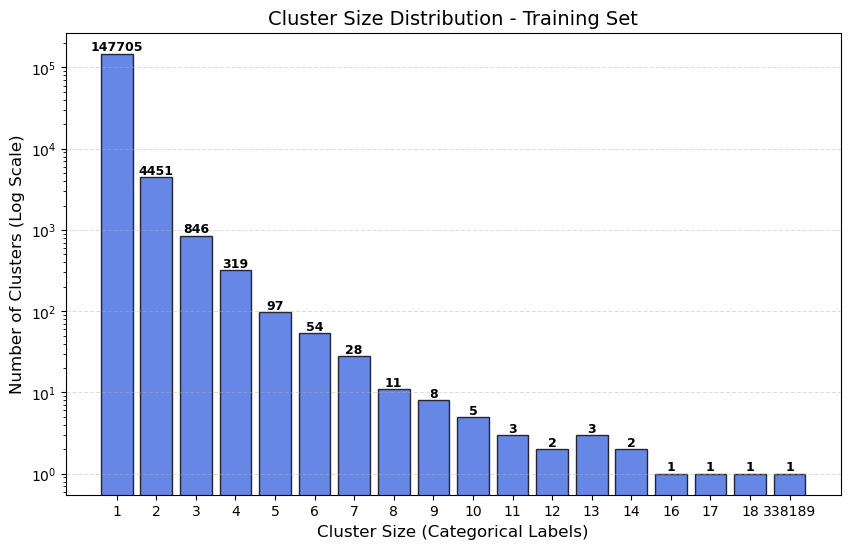


--- Starting Connectivity Analysis for: Validation Set ---
[Validation Set] Cleaning and exploding references...
[Validation Set] Building the network graph...


Adding edges for Validation Set:   0%|          | 0/49931 [00:00<?, ?it/s]

[Validation Set] Identifying connected components...
------------------------------

Results for Validation Set
	Total Papers (Nodes): 150000
	Total Clusters (Connected Groups): 106941
	Largest Cluster Size: 25500 papers (17.00%)
	Smallest Cluster Size: 1 papers (0.00%)

	Cluster Size Distribution (Frequency):
		- Clusters of size 1: 97565
		- Clusters of size 2: 6226
		- Clusters of size 3: 1602
		- Clusters of size 4: 631
		- Clusters of size 5: 332
		- Clusters of size 6: 158
		- Clusters of size 7: 124
		- Clusters of size 8: 79
		- Clusters of size 9: 56
		- Clusters of size 10: 25
		- Clusters of size 11: 24
		- Clusters of size 12: 21
		- Clusters of size 13: 14
		- Clusters of size 14: 18
		- Clusters of size 15: 13
		- Clusters of size 16: 6
		- Clusters of size 17: 6
		- Clusters of size 18: 6
		- Clusters of size 19: 7
		- Clusters of size 20: 4
		- Clusters of size 21: 4
		- Clusters of size 22: 1
		- Clusters of size 23: 2
		- Clusters of size 24: 1
		- Clusters of size 25

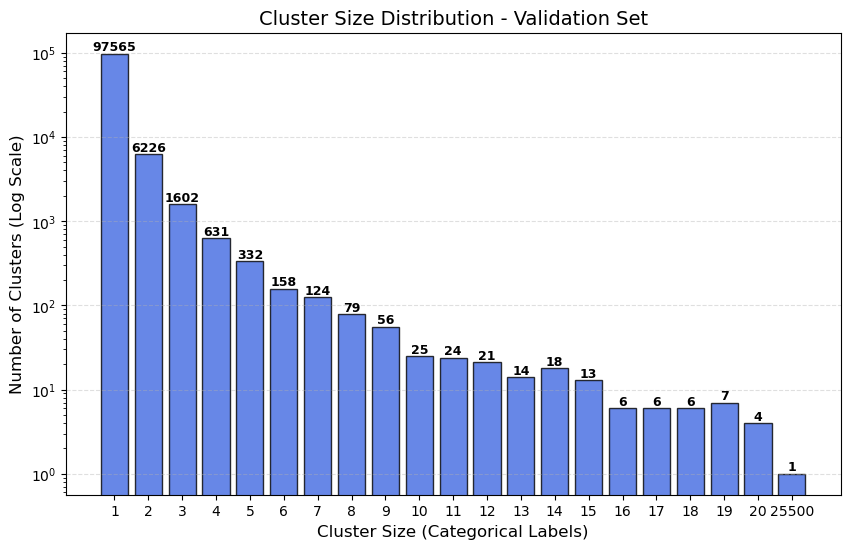


--- Starting Connectivity Analysis for: Test Set ---
[Test Set] Cleaning and exploding references...
[Test Set] Building the network graph...


Adding edges for Test Set:   0%|          | 0/51595 [00:00<?, ?it/s]

[Test Set] Identifying connected components...
------------------------------

Results for Test Set
	Total Papers (Nodes): 150000
	Total Clusters (Connected Groups): 107395
	Largest Cluster Size: 29488 papers (19.66%)
	Smallest Cluster Size: 1 papers (0.00%)

	Cluster Size Distribution (Frequency):
		- Clusters of size 1: 99568
		- Clusters of size 2: 5467
		- Clusters of size 3: 1317
		- Clusters of size 4: 473
		- Clusters of size 5: 204
		- Clusters of size 6: 126
		- Clusters of size 7: 80
		- Clusters of size 8: 47
		- Clusters of size 9: 27
		- Clusters of size 10: 22
		- Clusters of size 11: 13
		- Clusters of size 12: 11
		- Clusters of size 13: 5
		- Clusters of size 14: 7
		- Clusters of size 15: 4
		- Clusters of size 16: 5
		- Clusters of size 17: 1
		- Clusters of size 18: 3
		- Clusters of size 19: 3
		- Clusters of size 20: 3
		- Clusters of size 21: 1
		- Clusters of size 22: 1
		- Clusters of size 23: 1
		- Clusters of size 25: 2
		- Clusters of size 28: 1
		- Clusters

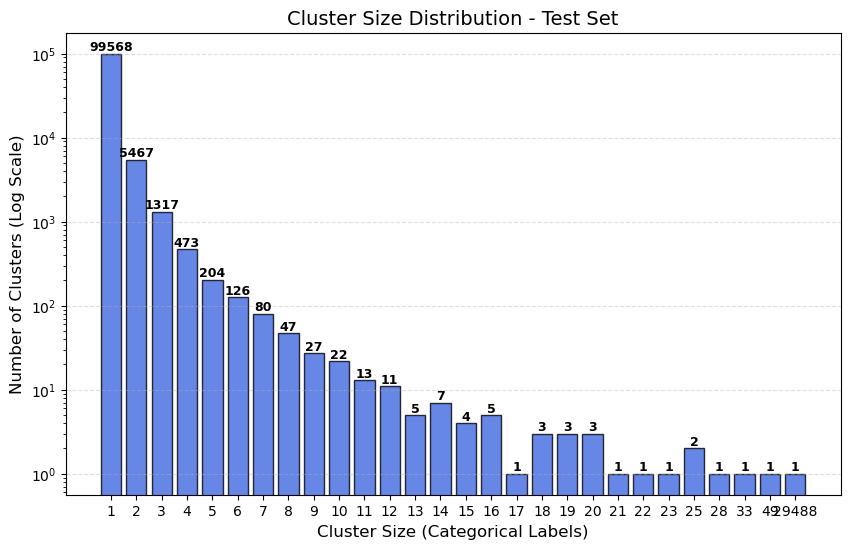

In [10]:
results_train = analyze_set_connectivity(train_chunk, "Training Set", show_graph=False, show_distribution=True)
results_val = analyze_set_connectivity(val_chunk, "Validation Set", show_graph=False, show_distribution=True)
results_test = analyze_set_connectivity(test_chunk, "Test Set", show_graph=False, show_distribution=True)

## 4. Target Identification

In [11]:
from joblib import Parallel, delayed
import pandas as pd
import gc
from pathlib import Path

SPLIT_DATA_PATH = Path("data/split")

def process_and_save_split(df: pd.DataFrame, split_name: str, seed: int) -> str:
    """Process the given DataFrame for a specific split and save it to a Parquet file."""
    raw_df = df.copy()
    
    if raw_df.empty:
        return f"{split_name}: empty"

    df = build_training_dataframe(
        raw_df,
        seed=seed,
        filter_years=True
    ).assign(split=split_name)

    output_path = SPLIT_DATA_PATH / f"{split_name}_pairs.parquet"
    df.to_parquet(output_path, index=False)

    del raw_df
    del df
    gc.collect()

    return f"{split_name}: saved to {output_path}"

In [12]:
# # TODO: to delete after Pioda usage
# # read parquets files into dataframes
# train_chunk = pd.read_parquet(f"{SPLIT_DATA_PATH}/train.parquet")
# val_chunk = pd.read_parquet(f"{SPLIT_DATA_PATH}/validation.parquet")
# test_chunk = pd.read_parquet(f"{SPLIT_DATA_PATH}/test.parquet")

In [13]:
# split_jobs = [(train_chunk, 'train', 42), (val_chunk, 'validation', 43), (test_chunk, 'test', 44)]

# results = Parallel(n_jobs=min(3, len(split_jobs)), backend='loky')(
#     delayed(process_and_save_split)(df, split_name, seed)
#     for df, split_name, seed in split_jobs
# )

# print(results)

# OLD

## 5. Export splitted data

In [ ]:
# if not os.path.exists(SPLIT_DATA_PATH):
#      os.makedirs(SPLIT_DATA_PATH)
     
# train_chunk.to_parquet(os.path.join(SPLIT_DATA_PATH, "train.parquet"))
# val_chunk.to_parquet(os.path.join(SPLIT_DATA_PATH, "validation.parquet"))  
# test_chunk.to_parquet(os.path.join(SPLIT_DATA_PATH, "test.parquet"))

## 5. Export splitted pairs (data-target) data

In [15]:
# if not os.path.exists(SPLIT_DATA_PATH):
#      os.makedirs(SPLIT_DATA_PATH)

# train_pairs, val_pairs, test_pairs = ...
# train_pairs.to_parquet(os.path.join(SPLIT_DATA_PATH, "train_pairs.parquet"))
# val_pairs.to_parquet(os.path.join(SPLIT_DATA_PATH, "validation_pairs.parquet"))  
# test_pairs.to_parquet(os.path.join(SPLIT_DATA_PATH, "test_pairs.parquet"))